# 4. Download & measure the depth rasters

Everything so far was free (index only). When you want the actual water-depth GeoTIFFs,
`.download()` fetches and crops **only** the events you selected, and returns the catalogue
itself, now carrying its files, so the result stays *actionable*. When you run this
interactively you'll see a **download progress bar**.

> This tutorial downloads real rasters, so it needs network access (it does not run in the
> offline test suite).

In [1]:
from pathlib import Path

import euroflood as ef

ef.settings.output_dir = Path("out")  # write crops here (relative, tidy)

cat = ef.floods("Zutphen, Netherlands", shape="bbox")  # bbox ROI (tutorial 02)

Download a couple of events. Downloads are **cached**: re-running reuses the existing crops
(nothing is re-fetched) unless you pass `force=True`.

In [2]:
dl = cat.head(2).download()
dl  # repr shows "… · ⬇ 2/2 downloaded"

,collection,event_id,date,year,end_date,cluster_id,filename,download_url,area_km2,geometry,path
0,historic,4049036842,2019-03-04,2019,2019-04-08,333,WD_MERGE_2019-03-04---2019-04-08_duration_28_d...,https://jeodpp.jrc.ec.europa.eu/ftp/jrc-openda...,6.889,"POLYGON ((6.14039 52.08873, 6.27499 52.08873, ...",out/flood_2019-03-04_id4049036842_8277ba1c.tif
1,historic,1407437849,2024-02-05,2024,2024-03-11,345,WD_MERGE_2024-02-05---2024-03-11_duration_28_d...,https://jeodpp.jrc.ec.europa.eu/ftp/jrc-openda...,0.438,"POLYGON ((6.14039 52.08873, 6.27499 52.08873, ...",out/flood_2024-02-05_id1407437849_8277ba1c.tif


In [3]:
dl.files

[PosixPath('out/flood_2019-03-04_id4049036842_8277ba1c.tif'),
 PosixPath('out/flood_2024-02-05_id1407437849_8277ba1c.tif')]

## Render a downloaded depth map

`.plot(depth=True)` renders the downloaded rasters. When a selection spans several events it
shows their per-pixel maximum; a guardrail caps auto-downloads at 4 rasters unless you pass
`limit=` or filter first.

<Axes: title={'center': 'Flood depth: max of 2 events'}>

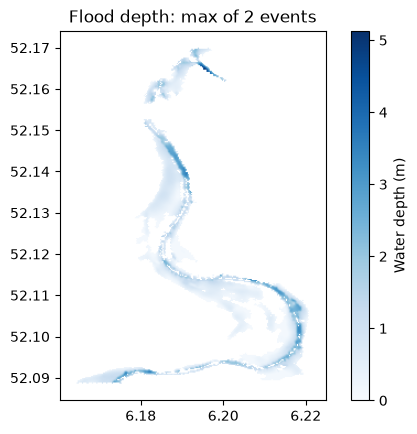

In [4]:
dl.plot(depth=True)

## Work with a single raster: `DepthRaster`

`.depths()` returns lightweight `DepthRaster` objects (also `ef.open_depth(path)`). Each can
`read()` its array, `plot()` / `explore()` itself, and `save()` to a `.png` or `.html`:

In [5]:
depth = dl.depths()[0]
array, _transform, crs, _nodata = depth.read()
print(
    "shape:",
    array.shape,
    "| CRS:",
    crs,
    "| max (m):",
    round(float(array.max()) * 0.01, 2),
)

shape: (451, 739) | CRS: EPSG:4326 | max (m): 5.28



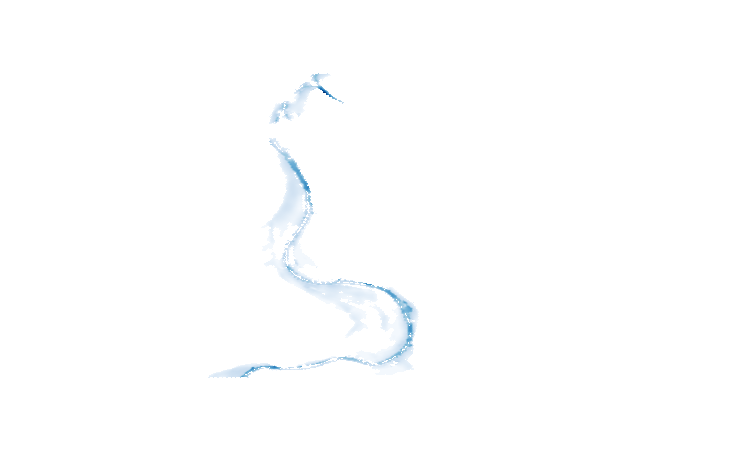

In [6]:
depth.explore(tiles="grayscale")  # a single event's depth as an interactive overlay

```python
depth.save("zutphen_depth.png")    # static image (by extension)
depth.save("zutphen_depth.html")   # interactive map
```

## Measure them: no network, reads the cached rasters

`.stats()` is a per-event table (max / mean / p95 depth in metres, flooded area in km², water
volume); `.summary()` is the aggregate envelope across all downloaded events. EFAS depth is in
centimetres and is scaled to metres automatically (pass `scale=1.0` to keep raw units).

In [7]:
dl.stats()

,event_id,date,wet_pixels,max_depth_m,mean_depth_m,p95_depth_m,flooded_area_km2,volume_m3,volume_Mm3
0,4049036842,2019-03-04,12463,5.57,0.830,2.45,4.9852,4138560.0,4.1386
1,1407437849,2024-02-05,582,0.38,0.176,0.31,0.2328,41068.0,0.0411


In [8]:
dl.summary()

{'wet_pixels': 8206,
 'max_depth_m': 5.13,
 'mean_depth_m': 0.827,
 'p95_depth_m': 2.32,
 'flooded_area_km2': 4.959,
 'volume_m3': 4100334.1,
 'volume_Mm3': 4.1003,
 'n_events': 2}

## Downloads persist across sessions

A later query of the same area (to the same output dir) automatically finds the crops already
on disk and pre-fills its `path` column, so you don't need to `.download()` again:

In [9]:
again = ef.floods("Zutphen, Netherlands", shape="bbox")  # same ROI -> finds the crops
f"{len(again.files)}/{len(again)} already downloaded"

'8/30 already downloaded'